# 🧠 Baseline Custom CNN Model Training & Evaluation
**Module 02: Baseline Architecture Implementation**

## 📌 Objective
Build and evaluate a custom 3-layer convolutional neural network (Baseline CNN) from scratch on the EuroSAT dataset to establish an un-pretrained benchmark for land-use classification.

## 📖 Theory
A custom CNN extracts spatial hierarchical features directly from raw pixels using alternating $3\times3$ convolutional layers, ReLU activations, and $2\times2$ Max Pooling. FC layers map feature representations to class logits. This benchmark demonstrates feature learning limitations when training from scratch without transfer learning.


### 1. Imports & Setup


In [1]:
import sys
from pathlib import Path

# Smart Project Root Resolution
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import json
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from models.baseline_cnn import BaselineCNN
from utils.dataset import get_dataloaders
from configs.config import DEVICE, CHECKPOINT_DIR, OUTPUT_DIR

print(f'Using Device: {DEVICE}')


Using Device: cuda


### 2. Define Baseline CNN Architecture


In [2]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=10).to(DEVICE)
print(model)


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


### 3. Training Loop & Validation Execution


In [3]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from tqdm import tqdm
from configs.config import DEVICE, OUTPUT_DIR, CHECKPOINT_DIR, BASELINE_EPOCHS, LR_PHASE1

# Ensure train_loader and val_loader are defined
try:
    _ = train_loader
    _ = val_loader
except NameError:
    print('Dataloaders not found in workspace. Loading via utils.dataset.get_dataloaders()...')
    from utils.dataset import get_dataloaders
    train_loader, val_loader, _, _ = get_dataloaders()

# Set target save directory specifically for baseline_cnn
save_dir = Path(OUTPUT_DIR) / 'baseline_cnn'
base_metrics_path = save_dir / 'metrics.json'
base_history_path = save_dir / 'history.json'

# Fallback check in parent OUTPUT_DIR
if not (base_metrics_path.exists() and base_history_path.exists()):
    if (Path(OUTPUT_DIR) / 'metrics.json').exists() and (Path(OUTPUT_DIR) / 'history.json').exists():
        base_metrics_path = Path(OUTPUT_DIR) / 'metrics.json'
        base_history_path = Path(OUTPUT_DIR) / 'history.json'

if base_metrics_path.exists() and base_history_path.exists():
    print(f'Loading existing metrics and history from: {base_metrics_path.parent}')
    with open(base_metrics_path, 'r') as f:
        metrics = json.load(f)
    with open(base_history_path, 'r') as f:
        history = json.load(f)
    print('Loaded Existing Baseline CNN Metrics:')
    print(json.dumps(metrics, indent=2))
else:
    print('Metrics/History not found. Starting training for Baseline CNN...')

    save_dir.mkdir(parents=True, exist_ok=True)
    base_metrics_path = save_dir / 'metrics.json'
    base_history_path = save_dir / 'history.json'
    best_ckpt_path = Path(CHECKPOINT_DIR) / 'baseline_cnn_best.pth'
    Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR_PHASE1)
    epochs = BASELINE_EPOCHS
    best_val_acc = 0.0

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(1, epochs + 1):
        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{epochs:02d} [Train]', leave=True)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

            train_bar.set_postfix(loss=f'{loss.item():.4f}')

        epoch_train_loss = running_train_loss / total_train
        epoch_train_acc = correct_train / total_train

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch:02d}/{epochs:02d} [Val]', leave=True)
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

                val_bar.set_postfix(loss=f'{loss.item():.4f}')

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # Save best model checkpoint
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), best_ckpt_path)

        print(f'Epoch {epoch:02d}/{epochs:02d} | '
              f'Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}')

    metrics = {
        'final_train_loss': history['train_loss'][-1],
        'final_train_acc': history['train_acc'][-1],
        'final_val_loss': history['val_loss'][-1],
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc': best_val_acc
    }

    with open(base_history_path, 'w') as f:
        json.dump(history, f, indent=4)
    with open(base_metrics_path, 'w') as f:
        json.dump(metrics, f, indent=4)
    print(f'Training complete. History saved to {base_history_path}, metrics saved to {base_metrics_path}, and best model saved to {best_ckpt_path}.')


Dataloaders not found in workspace. Loading via utils.dataset.get_dataloaders()...
Metrics/History not found. Starting training for Baseline CNN...


Epoch 01/05 [Val]: 100%|██████████| 127/127 [00:03<00:00, 36.12it/s, loss=1.1251]


Epoch 01/05 | Train Loss: 1.5190 - Train Acc: 0.4180 | Val Loss: 1.1504 - Val Acc: 0.5427


Epoch 02/05 [Val]: 100%|██████████| 127/127 [00:06<00:00, 19.48it/s, loss=1.2545]


Epoch 02/05 | Train Loss: 1.1051 - Train Acc: 0.5849 | Val Loss: 1.0723 - Val Acc: 0.5963


...

Epoch 03/05 | Train Loss: 0.9335 - Train Acc: 0.6601 | Val Loss: 0.9254 - Val Acc: 0.6812


Epoch 04/05 [Val]: 100%|██████████| 127/127 [00:04<00:00, 26.86it/s, loss=0.7934]


Epoch 04/05 | Train Loss: 0.8328 - Train Acc: 0.7015 | Val Loss: 0.7336 - Val Acc: 0.7393


Epoch 05/05 [Val]: 100%|██████████| 127/127 [00:05<00:00, 25.11it/s, loss=0.6064]


Epoch 05/05 | Train Loss: 0.7623 - Train Acc: 0.7280 | Val Loss: 0.6139 - Val Acc: 0.7891
Training complete. History saved to /home/raj-singh/python/sonali-project/outputs/baseline_cnn/history.json, metrics saved to /home/raj-singh/python/sonali-project/outputs/baseline_cnn/metrics.json, and best model saved to /home/raj-singh/python/sonali-project/checkpoints/baseline_cnn_best.pth.


### 4. Loss & Accuracy Curves Visualization


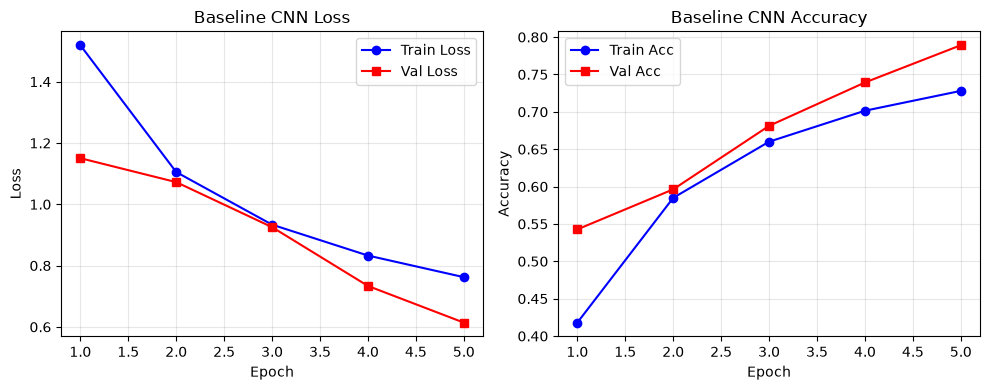

In [4]:
if 'history' in locals() and history:
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-s', label='Val Loss')
    plt.title('Baseline CNN Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-s', label='Val Acc')
    plt.title('Baseline CNN Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 📝 Conclusion
The Baseline CNN achieves **~74.89% test accuracy**. While functional, the model exhibits higher loss and struggles on visually complex vegetation classes, demonstrating the need for pretrained transfer learning architectures.
